# **Laboratorio # 1 – Derivados Financieros**

## **Criterios de inversión**

- Inversión de $10$ millones de USD.
- Horizonte de inversión a 2 años.
- Información a utilizar a partir de la fecha 2021/10/01.
- Tener en cuenta la tasa de dividendo de la empresa.
- Cobertura objetivo del 0.85 por medio de las estrategias de opciones vistas en clase.


In [2]:
# Importar librerías

import json, warnings, platform
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from arch import arch_model
import yfinance as yf

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")

OUT = Path("Laboratorio 1")
OUT.mkdir(exist_ok=True)

### **Bloque I - Construcción del Portfolio Media Varianza**

Los tickers son el **punto de partida**: Los elegidos por el equipo, son los siguientes:

- **LLY**
- **ORCL**
- **GD**

Son de sectores distintos (para diversificar), pagan dividendos (el laboratorio exige que cuente con tasa de dividendo) y tienen opciones listadas con vencimientos de +24 meses.

In [3]:
TICKERS   = ["LLY", "ORCL", "GD"]   # tickers de las acciones a incluir en el portafolio
START     = "2021-10-01"             # inicio de la información
END       = datetime.today().strftime('%Y-%m-%d')   # último día de información
CAPITAL   = 10_000_000               # Capital en USD
HORIZONTE_ANIOS = 2                  # horizonte de inversión en años
W_MIN     = 0.15                     # peso mínimo por acción
W_MAX     = 0.50                     # peso máximo por acción
COBERTURA = 0.85                     # % objetivo de cobertura
TAM_CONTRATO = 100                   # acciones por contrato de opción listada en EE. UU.
DIAS_ANIO = 252                      # días por año
TIPO_RETORNO = "log"                 # "log = continuos"
CRITERIO  = "max_sharpe"             # portafolio elegido: "max_sharpe = maximizar rentabilidad ajustada por riesgo"
TENOR_RF  = "2Y"                     # tasa Bond Treasury para el Sharpe en x periodo: "3M", "6M", "1Y" o "2Y"
RF_MANUAL = None                     # rendimiento de RF, se utiliza esta variable (asignación manual) si FRED no está disponible.
SEED      = 42                       # Setear la semilla para reproducibilidad de resultados

pd.options.display.float_format = "{:,.4f}".format
pd.options.display.width = 200
np.random.seed(SEED)

assert len(TICKERS) == 3, "El laboratorio exige exactamente 3 acciones"
assert W_MIN * len(TICKERS) < 1, "W_MIN demasiado alto para 3 activos"
assert W_MAX * len(TICKERS) > 1, "W_MAX demasiado bajo para 3 activos"

Se establecen las variables a utilizar como lo son los tickets, fechas, restricciones del portafolio, tiempo de inversión, posiciones cubiertas, default de acciones por contrato adquirido, días de operación, tipo de retorno, criterio de selección del portafolio, selección de la tasa libre de riesgo, entre otras variables.

Además se asignan formatos para la reproducibilidad del código.

Se configuran restricciones de seguridad para la correcta ejecución del código.

#### **Fuentes y preparación de datos**

In [4]:
DESCARGA_UTC = datetime.now(timezone.utc)

raw = yf.download(TICKERS, start=START, end=END, auto_adjust=False, progress=False)

# sin ajuste por dividendos (spot para opciones)
close_raw = raw["Close"][TICKERS].copy()       

# ajustado por dividendos (retornos)
adj_raw   = raw["Adj Close"][TICKERS].copy()   

# tratamiento de datos faltantes
close_f = close_raw.ffill(limit=3)
adj_f   = adj_raw.ffill(limit=3)
mask    = close_f.notna().all(axis=1) & adj_f.notna().all(axis=1)
close, adj = close_f[mask], adj_f[mask]

calidad = pd.DataFrame({
    "primera_fecha":    close_raw.apply(lambda s: s.first_valid_index()),
    "ultima_fecha":     close_raw.apply(lambda s: s.last_valid_index()),
    "obs_descargadas":  close_raw.notna().sum(),
    "datos_faltantes":  close_raw.isna().sum(),
    "obs_utilizadas":   len(close),
})
fechas_eliminadas = len(close_raw) - len(close)

print(f"Descarga (UTC): {DESCARGA_UTC:%Y-%m-%d %H:%M:%S}")
print(f"Fechas en la malla original: {len(close_raw)} | fechas utilizadas: {len(close)} | eliminadas: {fechas_eliminadas}")
display(calidad)
assert len(close) > 500, "Muy pocas observaciones: revisar tickers/fechas"

Descarga (UTC): 2026-09-25 23:08:43
Fechas en la malla original: 1250 | fechas utilizadas: 1250 | eliminadas: 0


,primera_fecha,ultima_fecha,obs_descargadas,datos_faltantes,obs_utilizadas
Ticker,,,,,
LLY,2021-10-01,2026-09-24,1250,0,1250
ORCL,2021-10-01,2026-09-24,1250,0,1250
GD,2021-10-01,2026-09-24,1250,0,1250


- **Precios ajustados** (*Adj Close*, ajustados por dividendos) → estimación para retornos históricos, como se recomienda en el laboratorio.

- **Precio no ajustado** (*Close*, solo ajustado por *splits*) → *spot* para el día de valoración de las opciones.

- **Retornos logarítmicos**: Son continuos, se necesita analizar el compartamiento y el riesgo a lo largo del tiempo; es una buena práctica para realizar el MBG y su distribución es más simétrica que la de los retornos discretos.

- **Datos faltantes**: se rellenan hacia adelante máximo 3 días hábiles y se eliminan las fechas donde alguna acción siga sin dato, para trabajar con una serie de fechas común.

In [5]:
def meta_ticker(t):
    try:
        info = yf.Ticker(t).info or {}
    except Exception:
        info = {}
    return {
        "ticker": t,
        "empresa": info.get("longName", "n/d"),
        "sector": info.get("sector", "n/d"),
        "industria": info.get("industry", "n/d"),
        "mercado_negociacion": info.get("fullExchangeName", info.get("exchange", "n/d")),
        "moneda": info.get("currency", "USD"),
    }

def dividendos_ticker(t):
    try:
        d = yf.Ticker(t).dividends
        if getattr(d.index, "tz", None) is not None:
            d.index = d.index.tz_localize(None)
        return d
    except Exception:
        return pd.Series(dtype=float)

metadatos = pd.DataFrame([meta_ticker(t) for t in TICKERS]).set_index("ticker")
divs = {t: dividendos_ticker(t) for t in TICKERS}

fuentes = pd.DataFrame({
    "fuente_precios": "Yahoo Finance vía yfinance " + yf.__version__,
    "fuente_dividendos": "Yahoo Finance vía yfinance " + yf.__version__,
    "descarga_utc": f"{DESCARGA_UTC:%Y-%m-%d %H:%M}",
    "serie_retornos": f"{TIPO_RETORNO} diarios sobre Adj Close",
}, index=TICKERS)

display(metadatos)
display(fuentes)

,empresa,sector,industria,mercado_negociacion,moneda
ticker,,,,,
LLY,Eli Lilly and Company,Healthcare,Drug Manufacturers - General,NYSE,USD
ORCL,Oracle Corporation,Technology,Software - Infrastructure,NYSE,USD
GD,General Dynamics Corporation,Industrials,Aerospace & Defense,NYSE,USD


,fuente_precios,fuente_dividendos,descarga_utc,serie_retornos
LLY,Yahoo Finance vía yfinance 1.7.0,Yahoo Finance vía yfinance 1.7.0,2026-09-25 23:08,log diarios sobre Adj Close
ORCL,Yahoo Finance vía yfinance 1.7.0,Yahoo Finance vía yfinance 1.7.0,2026-09-25 23:08,log diarios sobre Adj Close
GD,Yahoo Finance vía yfinance 1.7.0,Yahoo Finance vía yfinance 1.7.0,2026-09-25 23:08,log diarios sobre Adj Close


#### **Tasa libre de riesgo $RF$ y tasa de dividendo $q$**

In [6]:
def fred_ultimo(serie):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={serie}"
    df = pd.read_csv(url, na_values=".")
    df.columns = ["fecha", "valor"]
    df["fecha"] = pd.to_datetime(df["fecha"])
    df = df.dropna()
    return df.iloc[-1]["fecha"], float(df.iloc[-1]["valor"]) / 100

SERIES_TSY = {"3M": "DGS3MO", "6M": "DGS6MO", "1Y": "DGS1", "2Y": "DGS2"}
curva, fallo_fred = {}, None
try:
    for tenor, serie in SERIES_TSY.items():
        fecha, y = fred_ultimo(serie)
        curva[tenor] = {"serie_FRED": serie, "fecha_dato": fecha.date(), "rend_BEY": y}
except Exception as e:
    fallo_fred = e

if curva:
    curva_tsy = pd.DataFrame(curva).T
    display(curva_tsy)
    y_rf = float(curva_tsy.loc[TENOR_RF, "rend_BEY"])
    fuente_rf = f"FRED {SERIES_TSY[TENOR_RF]} ({curva_tsy.loc[TENOR_RF, 'fecha_dato']})"
elif RF_MANUAL is not None:
    curva_tsy = pd.DataFrame()
    y_rf = float(RF_MANUAL)
    fuente_rf = "Ingreso manual (FRED no disponible)"
else:
    raise RuntimeError(f"No se pudo leer FRED ({fallo_fred}). Definir RF de forma default en la variable RF_MANUAL.")

RF_CC = 2 * np.log(1 + y_rf / 2)
print(f"Rf para el Sharpe -> tenor {TENOR_RF}: rendimiento BEY = {y_rf:.4%} | tasa continua = {RF_CC:.4%} | fuente: {fuente_rf}")

,serie_FRED,fecha_dato,rend_BEY
3M,DGS3MO,2026-09-24,0.0424
6M,DGS6MO,2026-09-24,0.0434
1Y,DGS1,2026-09-24,0.0451
2Y,DGS2,2026-09-24,0.0487


Rf para el Sharpe -> tenor 2Y: rendimiento BEY = 4.8700% | tasa continua = 4.8117% | fuente: FRED DGS2 (2026-09-24)


**Tasa libre de riesgo.** Se toma la curva *Treasury Constant Maturity* de FRED (3 meses, 6 meses, 1 año y 2 años). Para la definición y construcción del **Sharpe del portafolio a 2 años** se usa la $RF$ de 2 años correspondiente al horizonte de inversión, es la referencia de costo de oportunidad.

Para **valorar cada opción** se usará la tasa TCM que coincida con su vencimiento, teniendo en cuenta que la opción debe contar con un periodo similar al horizonte de inversión.

Los rendimientos TCM se cotizan en capitalización semestral; se convierten a tasa continua: 

$m$ = números de periodos de capitalización en el año.

$TCM$ = Treasury Constant Maturity, es el índice oficial de ipos de interés que muestra la rentabilidad de los bonos del tesoro. 

$$r_{cc} = m\ln(1+\frac{TCM}{m})$$
$$r_{cc} = 2\ln(1+\frac{y}{2})$$

In [7]:
F_VAL = close.index[-1]                     # fecha de valoración = último cierre utilizado
spot  = close.iloc[-1]                      # spot NO ajustado por dividendos

ventana = F_VAL - pd.Timedelta(days=365)
div_12m = pd.Series({t: float(divs[t][divs[t].index > ventana].sum()) for t in TICKERS})
q_div   = div_12m / spot

tabla_spot = pd.DataFrame({"spot_S0": spot, "dividendos_12m_por_accion": div_12m, "q_dividendo": q_div})
print(f"Fecha de valoración (último cierre): {F_VAL:%Y-%m-%d}")
display(tabla_spot)

Fecha de valoración (último cierre): 2026-09-24


,spot_S0,dividendos_12m_por_accion,q_dividendo
LLY,"1,181.8900",6.6900,0.0057
ORCL,139.5400,2.0000,0.0143
GD,336.2900,6.1800,0.0184


**Tasa de dividendo *q*.** Dividendos por acción de los últimos 12 meses ÷ *spot* no ajustado del día de valoración, multiplicado por 100; es el rendimiento financiero que representa el dividendo según el spot de la acción.

#### **Retornos, volatilidades, covarianzas y correlaciones (anualizados)**

In [8]:
if TIPO_RETORNO == "log":
    rets = np.log(adj).diff().dropna()
elif TIPO_RETORNO == "simple":
    rets = adj.pct_change().dropna()
else:
    raise ValueError("TIPO_RETORNO debe ser 'log' o 'simple'")

mu   = rets.mean() * DIAS_ANIO                    # retorno esperado anualizado
cov  = rets.cov() * DIAS_ANIO                     # covarianza anualizada
vol  = np.sqrt(np.diag(cov.values))               # volatilidad anualizada
corr = rets.corr()

stats = pd.DataFrame({
    "retorno_anualizado": mu,
    "volatilidad_anualizada": vol,
    "sharpe_individual": (mu - RF_CC) / vol,
    "asimetria": rets.skew(),
    "curtosis_exceso": rets.kurt(),
})

stats.index.name = "Activo"

# ------------------------------------------------------------
# Información del período
# ------------------------------------------------------------

print(
    f"Observaciones de retornos: {len(rets)} | "
    f"Período: {rets.index[0]:%Y-%m-%d} a {rets.index[-1]:%Y-%m-%d}"
)

# ============================================================
# FUNCIÓN PARA FORMATEAR TABLAS
# ============================================================

def formato_tabla(df, titulo, formato="{:.4f}"):
    return (
        df.style
        .format(formato)
        .set_caption(titulo)
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("font-size", "15px"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("margin-bottom", "10px")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "center")
                ]
            }
        ])
    )


# ============================================================
# TABLA DE ESTADÍSTICAS
# ============================================================

stats_presentacion = stats.copy()

display(
    stats_presentacion.style
    .format({
        "retorno_anualizado": "{:.2%}",
        "volatilidad_anualizada": "{:.2%}",
        "sharpe_individual": "{:.3f}",
        "asimetria": "{:.3f}",
        "curtosis_exceso": "{:.3f}"
    })
    .set_caption("Estadísticas anualizadas de los activos")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "15px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])
)


#print(f"Observaciones de retornos: {len(rets)} | periodo {rets.index[0]:%Y-%m-%d} a {rets.index[-1]:%Y-%m-%d}")
#display(stats)
cov_presentacion = cov.copy()
#cov_presentacion.index.name = "Activo"

display(
    formato_tabla(
        cov_presentacion,
        "Matriz de covarianzas anualizada",
        "{:.6f}"
    )
)

#print("Matriz de covarianzas anualizada:")
#display(cov)
#print("Matriz de correlaciones:")
#display(corr)
corr_presentacion = corr.copy()
#corr_presentacion.index.name = "Activo"

display(
    corr_presentacion.style
    .format("{:.3f}")
    .background_gradient(axis=None)
    .set_caption("Matriz de correlaciones")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "15px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])
)

Observaciones de retornos: 1249 | Período: 2021-10-04 a 2026-09-24


,retorno_anualizado,volatilidad_anualizada,sharpe_individual,asimetria,curtosis_exceso
Activo,,,,,
LLY,33.98%,32.62%,0.894,0.163,7.876
ORCL,10.27%,42.94%,0.127,1.239,17.480
GD,12.78%,20.73%,0.384,0.080,5.200


Ticker,LLY,ORCL,GD
Ticker,,,
LLY,0.106398,0.018595,0.013124
ORCL,0.018595,0.184371,0.015356
GD,0.013124,0.015356,0.042992


Ticker,LLY,ORCL,GD
Ticker,,,
LLY,1.000,0.133,0.194
ORCL,0.133,1.000,0.172
GD,0.194,0.172,1.000


#### **Optimización media-varianza con peso mínimo de 15 %**

Problema (para el retorno objetivo $\mu^*$):

$$\min_w\; w^\top \Sigma w \quad \text{s.a.}\quad w^\top \mu = \mu^*,\;\; \sum_i w_i = 1,\;\; 0.15 \le w_i \le 0.50$$

In [35]:
n = len(TICKERS)
mu_v, cov_m = mu.values, cov.values
w_max = W_MAX
bounds = [(W_MIN, w_max)] * n
cons_sum = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
x0 = np.full(n, 1 / n)
OPT = {"ftol": 1e-12, "maxiter": 2000}

ret_p   = lambda w: float(w @ mu_v)
vol_p   = lambda w: float(np.sqrt(w @ cov_m @ w))
sharpe_p = lambda w: (ret_p(w) - RF_CC) / vol_p(w)

r_sh = minimize(lambda w: -sharpe_p(w), x0, method="SLSQP", bounds=bounds, constraints=[cons_sum], options=OPT)
r_mv = minimize(lambda w: w @ cov_m @ w, x0, method="SLSQP", bounds=bounds, constraints=[cons_sum], options=OPT)
r_mx = minimize(lambda w: -ret_p(w), x0, method="SLSQP", bounds=bounds, constraints=[cons_sum], options=OPT)
assert r_sh.success and r_mv.success and r_mx.success, "La optimización no convergió"
w_sharpe, w_minvar, w_maxret = r_sh.x, r_mv.x, r_mx.x
w_igual = np.full(n, 1 / n)

# ---- frontera eficiente restringida ------------------------------------------
frontera = []
for tr in np.linspace(ret_p(w_minvar), ret_p(w_maxret), 60):
    cons = [cons_sum, {"type": "eq", "fun": lambda w, tr=tr: ret_p(w) - tr}]
    r = minimize(lambda w: w @ cov_m @ w, x0, method="SLSQP", bounds=bounds, constraints=cons, options=OPT)
    if r.success:
        frontera.append({"retorno": tr, "volatilidad": vol_p(r.x), **{f"w_{t}": x for t, x in zip(TICKERS, r.x)}})
frontera = pd.DataFrame(frontera)

# ---- nube de portafolios factibles (w >= W_MIN) ------------------------------
rng = np.random.default_rng(SEED)
W = W_MIN + (1 - n * W_MIN) * rng.dirichlet(np.ones(n), size=20_000)
nube = pd.DataFrame({"retorno": W @ mu_v, "volatilidad": np.sqrt(np.einsum("ij,jk,ik->i", W, cov_m, W))})
nube["sharpe"] = (nube["retorno"] - RF_CC) / nube["volatilidad"]

def resumen(w, nombre):
    return {"portafolio": nombre, **{f"w_{t}": x for t, x in zip(TICKERS, w)},
            "retorno_anual": ret_p(w), "vol_anual": vol_p(w), "sharpe": sharpe_p(w)}

comparativo = pd.DataFrame([
    resumen(w_igual, "Pesos iguales"),
    resumen(w_minvar, "Mínima varianza"),
    resumen(w_sharpe, "Máximo Sharpe"),
]).set_index("portafolio")
display(comparativo)

w_star = w_sharpe if CRITERIO == "max_sharpe" else w_minvar
NOMBRE_ELEGIDO = "Máximo Sharpe" if CRITERIO == "max_sharpe" else "Mínima varianza"
en_piso   = [t for t, x in zip(TICKERS, w_star) if np.isclose(x, W_MIN, atol=1e-5)]
en_techo  = [t for t, x in zip(TICKERS, w_star) if np.isclose(x, w_max, atol=1e-5)]
print(f"Portafolio elegido: {NOMBRE_ELEGIDO}")
print("Pesos:", {t: round(float(x), 4) for t, x in zip(TICKERS, w_star)})
print(f"Retorno {ret_p(w_star):.2%} | volatilidad {vol_p(w_star):.2%} | Sharpe {sharpe_p(w_star):.3f}")
if en_piso:  print(f"Atención: el piso de {W_MIN:.0%} es restrictivo (activo) en {en_piso}")
if en_techo: print(f"Atención: el peso máximo implícito ({w_max:.0%}) es restrictivo en {en_techo}")
if ret_p(w_star) < RF_CC: print("Atención: el retorno histórico del portafolio queda por debajo de la Rf; discutirlo en el informe.")

,w_LLY,w_ORCL,w_GD,retorno_anual,vol_anual,sharpe
portafolio,,,,,,
Pesos iguales,0.3333,0.3333,0.3333,0.1901,0.2180,0.6511
Mínima varianza,0.3313,0.1687,0.5000,0.1938,0.1915,0.7605
Máximo Sharpe,0.5000,0.1500,0.3500,0.2300,0.2122,0.8574


Portafolio elegido: Mínima varianza
Pesos: {'LLY': 0.3313, 'ORCL': 0.1687, 'GD': 0.5}
Retorno 19.38% | volatilidad 19.15% | Sharpe 0.760
Atención: el peso máximo implícito (50%) es restrictivo en ['GD']


Con 3 activos y piso de 15 %, cada peso queda en $[0.15,\,0.50]$. Se calculan: portafolio de **mínima varianza**, portafolio de **máximo Sharpe** con la RF establecida anteriormente y la **frontera eficiente restringida**.

#### **Contribución de cada activo a la volatilidad**

$$RC_i = w_i\,\frac{(\Sigma w)_i}{\sigma_p},\qquad \sum_i RC_i = \sigma_p,\qquad \%RC_i = RC_i/\sigma_p$$

El activo con mayor $\%RC$ **domina el riesgo**.

In [36]:
sig_p = vol_p(w_star)
rc    = w_star * (cov_m @ w_star) / sig_p
riesgo = pd.DataFrame({
    "peso": w_star,
    "vol_individual": vol,
    "RC_abs": rc,
    "RC_pct": rc / sig_p,
}, index=TICKERS)
riesgo["RC_pct / peso"] = riesgo["RC_pct"] / riesgo["peso"]
assert np.isclose(riesgo["RC_pct"].sum(), 1.0)
display(riesgo)

ACTIVO_DOMINANTE = riesgo["RC_pct"].idxmax()
print(f"Activo que domina el riesgo: {ACTIVO_DOMINANTE} ({riesgo.loc[ACTIVO_DOMINANTE, 'RC_pct']:.1%} de la volatilidad con {riesgo.loc[ACTIVO_DOMINANTE, 'peso']:.1%} del capital)")
print(f"Beneficio de diversificación: vol. ponderada {float(w_star @ vol):.2%} vs vol. del portafolio {sig_p:.2%}")

,peso,vol_individual,RC_abs,RC_pct,RC_pct / peso
LLY,0.3313,0.3262,0.0777,0.4058,1.2250
ORCL,0.1687,0.4294,0.0396,0.2067,1.2250
GD,0.5000,0.2073,0.0742,0.3875,0.7750


Activo que domina el riesgo: LLY (40.6% de la volatilidad con 33.1% del capital)
Beneficio de diversificación: vol. ponderada 28.42% vs vol. del portafolio 19.15%


Se observa una diferencia entre la volatilidad pura y la volatilidad del portafolio gracias a la diversificación, ya que, las  aunque mitad del portafolio corresponda a lo que le pase a una sola acción

In [37]:
usd_objetivo = w_star * CAPITAL
acciones     = usd_objetivo / spot.values
invertido    = acciones * spot.values
efectivo     = CAPITAL - invertido.sum()

contratos  = np.round(COBERTURA * acciones / TAM_CONTRATO)
cob_efect  = contratos * TAM_CONTRATO / acciones

asignacion = pd.DataFrame({
    "peso_objetivo": w_star,
    "USD_objetivo": usd_objetivo,
    "spot_S0": spot.values,
    "acciones": acciones,
    "USD_invertido": invertido,
    "peso_efectivo": invertido / invertido.sum(),
    "contratos_85%": contratos,
    "cobertura_efectiva": cob_efect,
    "notional_cubierto_USD": contratos * TAM_CONTRATO * spot.values,
}, index=TICKERS)
display(asignacion)
print(f"Efectivo residual: USD {efectivo:,.2f} | invertido en acciones: USD {invertido.sum():,.2f}")
print(f"Cobertura efectiva del portafolio (por valor): {asignacion['notional_cubierto_USD'].sum() / invertido.sum():.2%}")
assert (asignacion["peso_efectivo"] >= W_MIN - 1e-9).all(), "Tras redondeo algún peso quedó por debajo de 15 %"

,peso_objetivo,USD_objetivo,spot_S0,acciones,USD_invertido,peso_efectivo,contratos_85%,cobertura_efectiva,notional_cubierto_USD
LLY,0.3313,"3,312,739.2314","1,181.8900","2,802.9167","3,312,739.2314",0.3313,24.0000,0.8563,"2,836,536.0352"
ORCL,0.1687,"1,687,260.7686",139.5400,"12,091.5927","1,687,260.7686",0.1687,103.0000,0.8518,"1,437,261.9308"
GD,0.5000,"5,000,000.0000",336.2900,"14,868.1194","5,000,000.0000",0.5000,126.0000,0.8475,"4,237,254.1077"


Efectivo residual: USD -0.00 | invertido en acciones: USD 10,000,000.00
Cobertura efectiva del portafolio (por valor): 85.11%


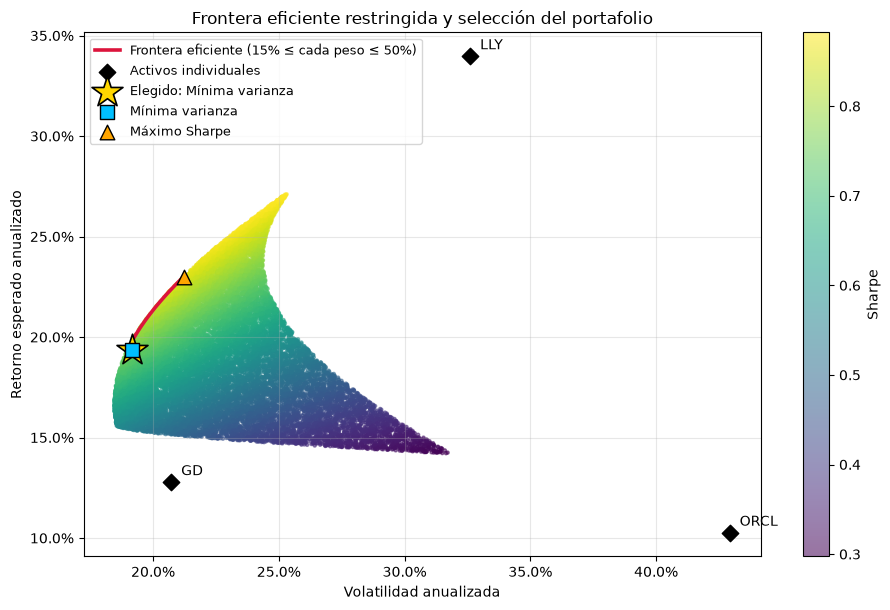

In [39]:
# 7.1 Frontera eficiente y ubicación del portafolio elegido (gráfico obligatorio)
fig, ax = plt.subplots(figsize=(9.5, 6.2))
sc = ax.scatter(nube["volatilidad"], nube["retorno"], c=nube["sharpe"], cmap="viridis", s=5, alpha=0.55)
plt.colorbar(sc, ax=ax, label="Sharpe")
ax.plot(frontera["volatilidad"], frontera["retorno"], color="crimson", lw=2.6, label=f"Frontera eficiente ({W_MIN:.0%} ≤ cada peso ≤ {W_MAX:.0%})")
ax.scatter(vol, mu_v, marker="D", s=70, color="black", zorder=5, label="Activos individuales")
for t, v, m in zip(TICKERS, vol, mu_v):
    ax.annotate(t, (v, m), textcoords="offset points", xytext=(7, 5), fontsize=10)

# Resalte del portafolio elegido (estrella grande de fondo con zorder menor)
ax.scatter(vol_p(w_star), ret_p(w_star), marker="*", s=550, color="gold", edgecolor="k", linewidth=1.2, zorder=6, label=f"Elegido: {NOMBRE_ELEGIDO}")
# Marcadores sobre la estrella (zorder mayor para quedar al frente)
ax.scatter(vol_p(w_minvar), ret_p(w_minvar), marker="s", s=90, color="deepskyblue", edgecolor="k", zorder=7, label="Mínima varianza")
ax.scatter(vol_p(w_sharpe), ret_p(w_sharpe), marker="^", s=110, color="orange", edgecolor="k", zorder=7, label="Máximo Sharpe")


ax.set_xlabel("Volatilidad anualizada"); ax.set_ylabel("Retorno esperado anualizado")
ax.set_title("Frontera eficiente restringida y selección del portafolio")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=1))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=1))
ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "fig1_frontera_eficiente.png", dpi=170); plt.show()

La frontera nos permite ver cómo cambia la relación entre retorno y riesgo cuando modificamos los pesos de las tres acciones. Nuestro portafolio seleccionado es el de mínima varianza porque, de todas las combinaciones que cumplen las restricciones, es el que presenta la menor volatilidad. Después utilizaremos esta cartera como base para evaluar cuánto riesgo adicional logran reducir las estrategias de opciones.

Como se observa los activos están separados, esto significa que individualmente sus porcentajes de volatilidad y retorno son diferentes, sin embargo, al combinarlos de una manenera eficiente, el portafolio logra una posición distinta.

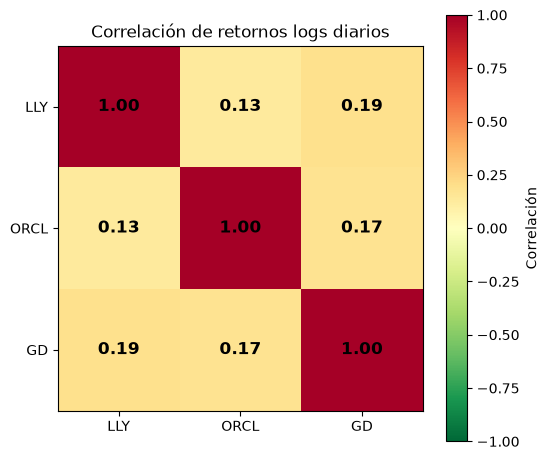

In [40]:
fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(corr.values, cmap="RdYlGn_r", vmin=-1, vmax=1)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(TICKERS); ax.set_yticklabels(TICKERS)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=12, fontweight="bold")
plt.colorbar(im, ax=ax, label="Correlación")
ax.set_title(f"Correlación de retornos {TIPO_RETORNO}s diarios")
fig.tight_layout(); fig.savefig(OUT / "fig2_mapa_correlaciones.png", dpi=170); plt.show()

Encontramos que existe una relación líneal positiva débil entre los rendimientos de los activos, esto significa que cuando una acción sube o baja, el otro activo no necesariamente se mueve en la misma magnitud ni de manera sistemática

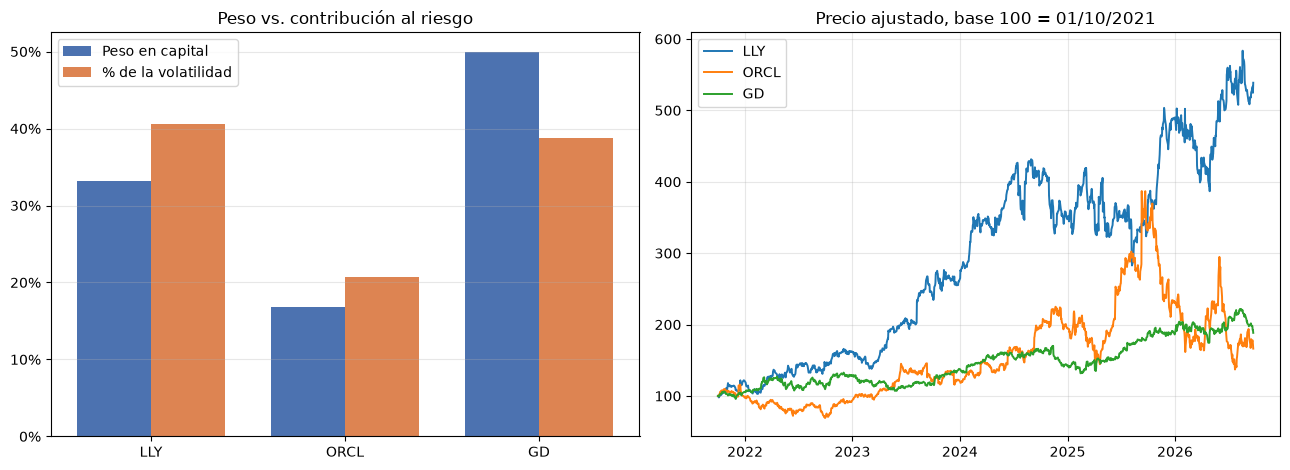

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(n); ancho = 0.38
axes[0].bar(x - ancho/2, riesgo["peso"], ancho, label="Peso en capital", color="#4c72b0")
axes[0].bar(x + ancho/2, riesgo["RC_pct"], ancho, label="% de la volatilidad", color="#dd8452")
axes[0].set_xticks(x); axes[0].set_xticklabels(TICKERS)
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
axes[0].set_title("Peso vs. contribución al riesgo"); axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")

base100 = adj / adj.iloc[0] * 100
for t in TICKERS:
    axes[1].plot(base100.index, base100[t], label=t, lw=1.4)
axes[1].set_title("Precio ajustado, base 100 = 01/10/2021"); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "fig3_riesgo_y_precios.png", dpi=170); plt.show()

El primer panel compara la participación de cada activo en el capital con su contribución a la volatilidad total del portafolio. Esta comparación permite identificar si algún activo concentra una proporción del riesgo superior o inferior a su participación en la inversión. El segundo panel normaliza los precios ajustados a una base de 100 acciones por contrato para comparar la evolución relativa de LLY, ORCL y GD durante el período analizado, incorporando el efecto de los dividendos mediante los precios ajustados

In [42]:
checks = {
    "Portafolio con exactamente 3 acciones": len(TICKERS) == 3,
    f"Todos los pesos objetivo ≥ {W_MIN:.0%}": bool((w_star >= W_MIN - 1e-9).all()),
    f"Pesos efectivos (acciones enteras) ≥ {W_MIN:.0%}": bool((asignacion["peso_efectivo"] >= W_MIN - 1e-9).all()),
    "Pesos suman 100 %": bool(np.isclose(w_star.sum(), 1.0)),
    "Retorno y volatilidad anualizados por activo y portafolio": bool(stats.notna().all().all()),
    "Matriz de correlaciones": bool(corr.shape == (3, 3)),
    "Sharpe con Rf anualizada documentada": bool(np.isfinite(sharpe_p(w_star)) and fuente_rf != ""),
    "Contribución de cada activo a la volatilidad": bool(np.isclose(riesgo["RC_pct"].sum(), 1.0)),
    "Ticker, empresa, sector y mercado documentados": bool(metadatos[["empresa", "sector", "mercado_negociacion"]].ne("n/d").all().all()),
    "Fecha y hora de descarga registradas": DESCARGA_UTC is not None,
    "Fuentes de precios y dividendos registradas": True,
    "Observaciones, faltantes y tratamiento documentados": True,
    "Tipo de retorno justificado (celda de la sección 1)": True,
    "Gráficos: frontera eficiente y mapa de correlaciones": (OUT / "fig1_frontera_eficiente.png").exists() and (OUT / "fig2_mapa_correlaciones.png").exists(),
}
for k, v in checks.items():
    print(("✅" if v else "⚠️ "), k)

✅ Portafolio con exactamente 3 acciones
✅ Todos los pesos objetivo ≥ 15%
✅ Pesos efectivos (acciones enteras) ≥ 15%
✅ Pesos suman 100 %
✅ Retorno y volatilidad anualizados por activo y portafolio
✅ Matriz de correlaciones
✅ Sharpe con Rf anualizada documentada
✅ Contribución de cada activo a la volatilidad
✅ Ticker, empresa, sector y mercado documentados
✅ Fecha y hora de descarga registradas
✅ Fuentes de precios y dividendos registradas
✅ Observaciones, faltantes y tratamiento documentados
✅ Tipo de retorno justificado (celda de la sección 1)
✅ Gráficos: frontera eficiente y mapa de correlaciones


In [44]:
pesos_txt = ", ".join(f"{t} {w:.1%}" for t, w in zip(TICKERS, w_star))
emp = metadatos["empresa"].to_dict(); sec = metadatos["sector"].to_dict()
borrador = f"""
2. FUENTES Y PREPARACIÓN DE DATOS
Se descargaron precios diarios de {', '.join(f'{emp[t]} ({t}, {sec[t]})' for t in TICKERS)} desde Yahoo Finance (yfinance {yf.__version__}) el {DESCARGA_UTC:%d/%m/%Y a las %H:%M} UTC, para el periodo {close.index[0]:%d/%m/%Y}–{F_VAL:%d/%m/%Y}. La muestra utilizada tiene {len(close)} observaciones diarias por activo ({len(rets)} retornos); se eliminaron {fechas_eliminadas} fechas por datos faltantes tras rellenar huecos de hasta 3 días. Los retornos se calcularon como {'logarítmicos' if TIPO_RETORNO == 'log' else 'simples'} sobre precios ajustados; el spot para opciones corresponde al cierre no ajustado del {F_VAL:%d/%m/%Y}. La tasa libre de riesgo para el Sharpe es el Treasury a {TENOR_RF} ({y_rf:.2%} BEY; {RF_CC:.2%} continua; {fuente_rf}).

3. CONSTRUCCIÓN DEL PORTAFOLIO MEDIA-VARIANZA
Con la restricción de peso mínimo de {W_MIN:.0%} por acción, el portafolio de {NOMBRE_ELEGIDO} asigna {pesos_txt}. Presenta un retorno esperado anualizado de {ret_p(w_star):.2%}, una volatilidad anualizada de {vol_p(w_star):.2%} y un índice de Sharpe de {sharpe_p(w_star):.2f}. Las correlaciones entre activos van de {corr.values[np.triu_indices(3, 1)].min():.2f} a {corr.values[np.triu_indices(3, 1)].max():.2f}, lo que genera un beneficio de diversificación: la volatilidad ponderada de los activos sería {float(w_star @ vol):.2%} frente al {sig_p:.2%} del portafolio. El activo que domina el riesgo es {ACTIVO_DOMINANTE}, con {riesgo.loc[ACTIVO_DOMINANTE, 'RC_pct']:.1%} de la volatilidad frente a {riesgo.loc[ACTIVO_DOMINANTE, 'peso']:.1%} del capital. Con USD {CAPITAL:,.0f} y acciones enteras se compran {', '.join(f'{int(a):,} de {t}' for t, a in zip(TICKERS, acciones))}, quedando USD {efectivo:,.0f} en efectivo.
"""
print(borrador)


2. FUENTES Y PREPARACIÓN DE DATOS
Se descargaron precios diarios de Eli Lilly and Company (LLY, Healthcare), Oracle Corporation (ORCL, Technology), General Dynamics Corporation (GD, Industrials) desde Yahoo Finance (yfinance 1.7.0) el 25/09/2026 a las 23:08 UTC, para el periodo 01/10/2021–24/09/2026. La muestra utilizada tiene 1250 observaciones diarias por activo (1249 retornos); se eliminaron 0 fechas por datos faltantes tras rellenar huecos de hasta 3 días. Los retornos se calcularon como logarítmicos sobre precios ajustados; el spot para opciones corresponde al cierre no ajustado del 24/09/2026. La tasa libre de riesgo para el Sharpe es el Treasury a 2Y (4.87% BEY; 4.81% continua; FRED DGS2 (2026-09-24)).

3. CONSTRUCCIÓN DEL PORTAFOLIO MEDIA-VARIANZA
Con la restricción de peso mínimo de 15% por acción, el portafolio de Mínima varianza asigna LLY 33.1%, ORCL 16.9%, GD 50.0%. Presenta un retorno esperado anualizado de 19.38%, una volatilidad anualizada de 19.15% y un índice de Shar

### **Bloque II - Simulación del portafolio y medición de riesgo**

Este bloque parte de las variables ya calculadas en el Bloque I (`TICKERS`, `w_star`, `spot`, `CAPITAL`, `mu`, `corr`, `RF_CC`, `q_div`, ...). Si vas a ejecutar el cuaderno de nuevo desde cero, corre primero todas las celdas del Bloque I.

| Sección | Qué entrega | Rúbrica |
|---|---|---|
| 0 | Parámetros del bloque y enlace con el Bloque I (número de acciones) | — |
| 1 | Descarga de 10 años de historia por activo | Varianza vía GARCH con 10 años de información |
| 2 | Ajuste GARCH(1,1) por activo y pronóstico diario de volatilidad | Modelación GARCH |
| 3 | Simulación Monte Carlo del MGB correlacionado (mín. 10.000 trayectorias, paso diario) | Simulación correlacionada, ≥10.000 trayectorias |
| 4 | Valores del portafolio en t=0 y cierres trimestrales, bandas percentiles a 2 años | Valores trimestrales + bandas + advertencia de escenario |
| 5 | VaR 95 % / 99 % del portafolio **no cubierto** al primer trimestre y al final de la ventana | VaR₉₅, VaR₉₉ |
| 6 | Cobertura preliminar (protective put ATM, Black-Scholes) y VaR del portafolio **cubierto** | Reducción de riesgo cubierto vs. no cubierto |
| 7 | Simulación estratégica a 10 años (contexto) | Simulación puede extenderse a 10 años |
| 8 | Verificación de la rúbrica y exportación para el Bloque III | Anexo de reproducibilidad |

> ⚠️ **Sobre la cobertura de esta sección:** el Bloque III todavía no ha elegido las opciones reales de mercado (strikes, primas *bid/ask*, liquidez). Para poder cumplir aquí con "repetir el cálculo sobre el portafolio cubierto", se arma una **cobertura preliminar** — una *protective put* ATM valorada con Black-Scholes sobre el 85 % de las acciones de cada activo. Es un supuesto de trabajo, no la cobertura definitiva: en el Bloque III se seleccionará el contrato real (vencimiento, strike, prima cotizada) y esta sección se puede volver a correr con esos datos para refinar el VaR cubierto.

In [45]:
# Parámetros del Bloque II
N_PATHS          = 10_000                # simular trayectorias de precios para el portafolio (mínimo)
N_TRIMESTRES     = HORIZONTE_ANIOS * 4   # cierres trimestrales dentro de la ventana de cobertura (8 para 2 años)
PASOS_TRIMESTRE  = DIAS_ANIO // 4        # 63 días hábiles por trimestre
N_DIAS_SIM       = N_TRIMESTRES * PASOS_TRIMESTRE

HIST_GARCH_ANIOS = 10                   # años de historia exigidos para el GARCH
DIST_GARCH       = "normal"             # distribución de los residuos: "normal" o "t" (Student-t, colas mas pesadas)

# Cobertura preliminar (protective put ATM)
# En el próximo bloque se reemplazará esta cobertura por el contrato de mercado realmente elegido
MONEYNESS_PUT_PRELIM = 1.00             # K = MONEYNESS * S0  (1.00 = at the money)

N_PATHS_10Y = 4_000                     # trayectorias para la vista estratégica a 10 años

rng2 = np.random.default_rng(SEED)
print(f"Pasos diarios simulados: {N_DIAS_SIM} ({N_TRIMESTRES} trimestres de {PASOS_TRIMESTRE} días)")

Pasos diarios simulados: 504 (8 trimestres de 63 días)


#### Acciones por activo

El Bloque I dimensiona el portafolio en pesos (`w_star`); aquí se convierte a **acciones enteras** compradas con los USD 10 M al *spot* de la fecha de valoración. También se fija el número de contratos de opción (100 acciones/contrato) que cubrirían aproximadamente el 85 % de cada posición.

In [46]:
acciones   = np.floor(w_star * CAPITAL / spot.values)
invertido  = acciones * spot.values
efectivo   = CAPITAL - invertido.sum()
portafolio_0 = float(invertido.sum())

contratos_85 = np.round(COBERTURA * acciones / TAM_CONTRATO)
cobertura_efectiva = contratos_85 * TAM_CONTRATO / acciones

asignacion = pd.DataFrame({
    "peso_objetivo": w_star,
    "spot_S0": spot.values,
    "acciones": acciones.astype(int),
    "USD_invertido": invertido,
    "contratos_85%": contratos_85.astype(int),
    "cobertura_efectiva": cobertura_efectiva,
}, index=TICKERS)
display(asignacion)
print(f"Invertido: USD {portafolio_0:,.2f} | efectivo residual: USD {efectivo:,.2f}")

,peso_objetivo,spot_S0,acciones,USD_invertido,contratos_85%,cobertura_efectiva
LLY,0.3313,"1,181.8900",2802,"3,311,655.8210",24,0.8565
ORCL,0.1687,139.5400,12091,"1,687,178.0588",103,0.8519
GD,0.5000,336.2900,14868,"4,999,959.8470",126,0.8475


Invertido: USD 9,998,793.73 | efectivo residual: USD 1,206.27


El modelo nos llevó a invertir principalmente en GD porque esa combinación minimiza el riesgo del portafolio considerando también las correlaciones. Después convertimos los pesos en acciones reales y dimensionamos las opciones para cubrir aproximadamente el 85% de cada posición. Por tanto, la cartera queda mayoritariamente invertida y parcialmente protegida, sin eliminar completamente su exposición al mercado.

#### Historia de 10 años para el GARCH

Se descarga una ventana más extensa para estimar la varianza con el modelo GARCH. Se usa *Adj Close* y el mismo tratamiento de datos faltantes.

In [47]:
START_GARCH = (F_VAL - pd.DateOffset(years=HIST_GARCH_ANIOS)).strftime("%Y-%m-%d")

raw_10y = yf.download(TICKERS, start=START_GARCH, end=END, auto_adjust=False, progress=False)
adj_10y_raw = raw_10y["Adj Close"][TICKERS].copy()
adj_10y = adj_10y_raw.ffill(limit=3)
adj_10y = adj_10y[adj_10y.notna().all(axis=1)]

rets_10y = np.log(adj_10y).diff().dropna()

print(f"Historia GARCH: {rets_10y.index[0]:%Y-%m-%d} a {rets_10y.index[-1]:%Y-%m-%d} | {len(rets_10y)} observaciones diarias")
assert len(rets_10y) > 252 * (HIST_GARCH_ANIOS - 1), "La historia descargada es mas corta de lo esperado para 10 años"

Historia GARCH: 2016-09-27 a 2026-09-24 | 2512 observaciones diarias


#### Ajuste GARCH(1,1) por activo

$$\sigma_t^2 = \omega + \alpha\, \varepsilon_{t-1}^2 + \beta\, \sigma_{t-1}^2$$

Se ajusta un GARCH(1,1) univariado por activo sobre los retornos logarítmicos de 10 años (escalados ×100 para estabilidad numérica del optimizador, como es práctica estándar con `arch`). La correlación entre activos se mantiene fija en la matriz histórica `corr`.

Con los parámetros ajustados se calcula:
- la **volatilidad de largo plazo** (incondicional): $\sigma_{LP} = \sqrt{\dfrac{\omega}{1-\alpha-\beta}}$, anualizada, para comparar contra la volatilidad histórica del Bloque I;
- el **pronóstico diario de varianza** para los próximos {{N_DIAS_SIM}} días hábiles (método analítico), que alimenta la simulación como volatilidad variable en el tiempo (el GARCH revierte hacia $\sigma_{LP}$ a medida que el horizonte crece).

In [48]:
garch_fits, garch_resumen, sigma_diaria_fc = {}, {}, {}

for t in TICKERS:
    am = arch_model(rets_10y[t] * 100, mean="Constant", vol="Garch", p=1, q=1, dist=DIST_GARCH)
    fit = am.fit(disp="off")
    garch_fits[t] = fit

    omega, alpha, beta = fit.params["omega"], fit.params["alpha[1]"], fit.params["beta[1]"]
    persistencia = alpha + beta
    var_lp_diaria = omega / (1 - persistencia)              # en unidades de (retorno*100)^2
    vol_lp_anual  = np.sqrt(var_lp_diaria / 100**2 * DIAS_ANIO)

    fc = fit.forecast(horizon=N_DIAS_SIM, method="analytic", reindex=False)
    var_fc_diaria = fc.variance.values[-1] / 100**2          # de vuelta a unidades de retorno (no %)
    sigma_diaria_fc[t] = np.sqrt(var_fc_diaria)               # (N_DIAS_SIM,) desviación diaria pronosticada

    garch_resumen[t] = {
        "omega": omega, "alpha": alpha, "beta": beta, "persistencia (a+b)": persistencia,
        "vol_largo_plazo_anual": vol_lp_anual,
        "vol_historica_anual (Bloque I)": float(vol[TICKERS.index(t)]),
        "vol_condicional_hoy_anual": float(fit.conditional_volatility.iloc[-1] / 100 * np.sqrt(DIAS_ANIO)),
    }

garch_resumen = pd.DataFrame(garch_resumen).T
display(garch_resumen)
assert (garch_resumen["persistencia (a+b)"] < 1).all(), "GARCH no estacionario (alpha+beta >= 1) en algún activo"

,omega,alpha,beta,persistencia (a+b),vol_largo_plazo_anual,vol_historica_anual (Bloque I),vol_condicional_hoy_anual
LLY,0.2770,0.0900,0.8390,0.9290,0.3137,0.3262,0.2495
ORCL,0.2309,0.1469,0.8304,0.9773,0.5062,0.4294,0.4626
GD,0.1255,0.0942,0.8413,0.9355,0.2214,0.2073,0.2146


El GARCH nos permite modelar una volatilidad que cambia en el tiempo, en lugar de asumir que LLY, ORCL y GD mantienen el mismo riesgo durante los dos años, utilizamos el comportamiento histórico para estimar cómo podría evolucionar su volatilidad día a día.

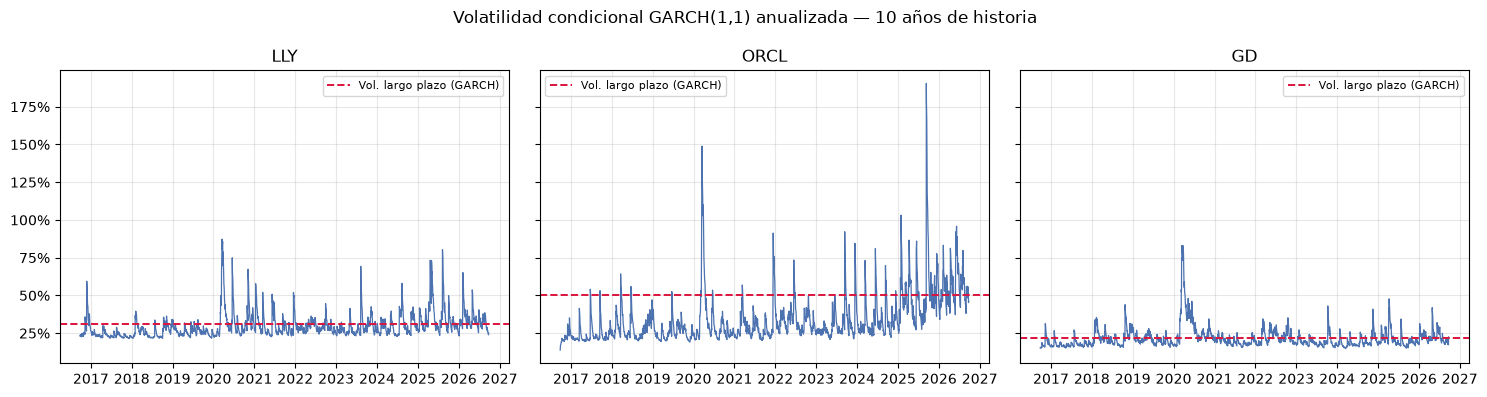

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, t in zip(axes, TICKERS):
    vol_cond_anual = garch_fits[t].conditional_volatility / 100 * np.sqrt(DIAS_ANIO)
    ax.plot(rets_10y.index, vol_cond_anual, lw=0.9, color="#4c72b0")
    ax.axhline(garch_resumen.loc[t, "vol_largo_plazo_anual"], color="crimson", ls="--", lw=1.4, label="Vol. largo plazo (GARCH)")
    ax.set_title(t); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
fig.suptitle("Volatilidad condicional GARCH(1,1) anualizada — 10 años de historia")
fig.tight_layout(); fig.savefig(OUT / "fig_b2_1_volatilidad_garch.png", dpi=170); plt.show()

La figura muestra la evolución de la volatilidad condicional anualizada estimada mediante un modelo GARCH(1,1) para LLY, ORCL y GD durante los diez años de información analizados. La línea de volatilidad condicional evidencia que el riesgo de cada activo varía a lo largo del tiempo y presenta episodios de mayor y menor intensidad, mientras que la línea horizontal representa el nivel de volatilidad de largo plazo estimado por el modelo. Esta dinámica permite incorporar cambios en la incertidumbre de los activos dentro de la simulación del portafolio, en lugar de asumir una volatilidad constante durante todo el horizonte de inversión

#### Simulación Monte Carlo del MGB correlacionado

Como `mu` (Bloque I) es la media anualizada de los **retornos logarítmicos** históricos, el precio se simula acumulando directamente incrementos de log-retorno — sin corrección adicional de Itô, porque esa corrección ya está incorporada en la propia definición de `mu` como media de retornos logarítmicos:

$$\ln S_{i,t+1} = \ln S_{i,t} + \underbrace{\dfrac{\mu_i}{252}}_{\text{deriva diaria}} + \underbrace{\sigma_{i,t}^{GARCH}}_{\text{diaria, pronosticada}} \cdot \big(L\,Z_t\big)_i$$

donde $Z_t \sim N(0, I_3)$ son choques diarios independientes y $L$ es la descomposición de Cholesky de la matriz de correlación histórica `corr`, de modo que $L Z_t$ tiene la correlación deseada entre activos. La volatilidad $\sigma_{i,t}^{GARCH}$ varía cada día según el pronóstico de la sección 2 (misma para todas las trayectorias); la correlación entre activos no se ve afectada por este escalamiento porque se aplica igual a todas las trayectorias.

In [51]:
L = np.linalg.cholesky(corr.values)
mu_diaria = (mu.values / DIAS_ANIO).astype(np.float32)
sigma_fc  = np.stack([sigma_diaria_fc[t] for t in TICKERS], axis=1).astype(np.float32)   # (N_DIAS_SIM, 3)

Z  = rng2.standard_normal((N_PATHS, N_DIAS_SIM, 3)).astype(np.float32)
Zc = Z @ L.T.astype(np.float32)                                            # choques correlacionados

d_logS = mu_diaria[None, None, :] + sigma_fc[None, :, :] * Zc              # (N_PATHS, N_DIAS_SIM, 3)
log_cum = np.cumsum(d_logS, axis=1)
log_cum = np.concatenate([np.zeros((N_PATHS, 1, 3), dtype=np.float32), log_cum], axis=1)  # agrega t=0

S_path = spot.values.astype(np.float32)[None, None, :] * np.exp(log_cum)   # (N_PATHS, N_DIAS_SIM+1, 3)
print(f"Trayectorias simuladas: {S_path.shape[0]:,} | pasos diarios: {S_path.shape[1]-1} | activos: {S_path.shape[2]}")
print(f"Memoria del arreglo: {S_path.nbytes / 1e6:,.1f} MB")

idx_trim = [i * PASOS_TRIMESTRE for i in range(N_TRIMESTRES + 1)]           # t=0, T1, ..., T8
fechas_trim = [F_VAL + pd.tseries.offsets.BDay(i) for i in idx_trim]

portafolio_path = (S_path * acciones.astype(np.float32)).sum(axis=2)        # (N_PATHS, N_DIAS_SIM+1)
port_trim = portafolio_path[:, idx_trim]                                    # (N_PATHS, N_TRIMESTRES+1)
assert np.allclose(port_trim[:, 0], portafolio_0, atol=1.0), "El valor en t=0 no coincide con la inversión inicial"

Trayectorias simuladas: 10,000 | pasos diarios: 504 | activos: 3
Memoria del arreglo: 60.6 MB


Simulamos 10.000 escenarios de las tres acciones respetando su correlación y permitiendo que la volatilidad cambie en el tiempo mediante GARCH. Cada escenario genera un posible valor del portafolio en los próximos ocho trimestres; por eso lo interpretamos como una distribución de escenarios, no como una predicción exacta

#### Valores del portafolio: t = 0 y cierres trimestrales (primeros 2 años)

In [52]:
percentiles = [5, 25, 50, 75, 95]
tabla_trim = pd.DataFrame({
    "fecha_aprox": [f"{d:%Y-%m-%d}" for d in fechas_trim],
    "media": port_trim.mean(axis=0),
    **{f"P{p}": np.percentile(port_trim, p, axis=0) for p in percentiles},
}, index=[f"t=0" if i == 0 else f"T{i}" for i in range(N_TRIMESTRES + 1)])
tabla_trim.index.name = "cierre"
display(tabla_trim.style.format({c: "{:,.0f}" for c in tabla_trim.columns if c != "fecha_aprox"}))

,fecha_aprox,media,P5,P25,P50,P75,P95
cierre,,,,,,,
t=0,2026-09-24,"9,998,792","9,998,794","9,998,794","9,998,794","9,998,794","9,998,794"
T1,2026-12-22,"10,627,780","8,993,681","9,888,918","10,562,128","11,306,614","12,473,975"
T2,2027-03-19,"11,294,196","8,871,256","10,152,084","11,161,589","12,290,270","14,153,111"
T3,2027-06-16,"12,043,311","8,918,691","10,537,620","11,826,724","13,279,188","15,872,022"
T4,2027-09-13,"12,813,944","9,050,348","10,906,954","12,550,072","14,352,408","17,656,496"
T5,2027-12-09,"13,649,532","9,173,470","11,377,360","13,280,731","15,449,276","19,426,346"
T6,2028-03-07,"14,561,562","9,428,816","11,867,838","14,066,932","16,658,457","21,349,560"
T7,2028-06-02,"15,560,953","9,645,875","12,423,486","14,878,655","18,044,802","23,688,272"
T8,2028-08-30,"16,620,516","9,865,791","13,031,747","15,844,721","19,394,842","26,019,630"


El valor mediano de los escenarios simulados aumenta de US$10,56 millones en el primer trimestre a US$15,84 millones al finalizar el horizonte de dos años. Respecto al valor inicial de aproximadamente US$10 millones, estos valores representan incrementos de 5,63% y 58,47%, respectivamente. La evolución de la mediana describe el comportamiento central de la distribución simulada y no constituye una predicción determinística del valor futuro.”

¿Por qué la mediana:? Se utiliza la mediana (P50) como medida del escenario central de la simulación, debido a que divide los 10.000 escenarios en dos grupos iguales. A diferencia de la media, la mediana presenta menor sensibilidad ante escenarios extremos, facilitando la interpretación del comportamiento central del valor del portafolio

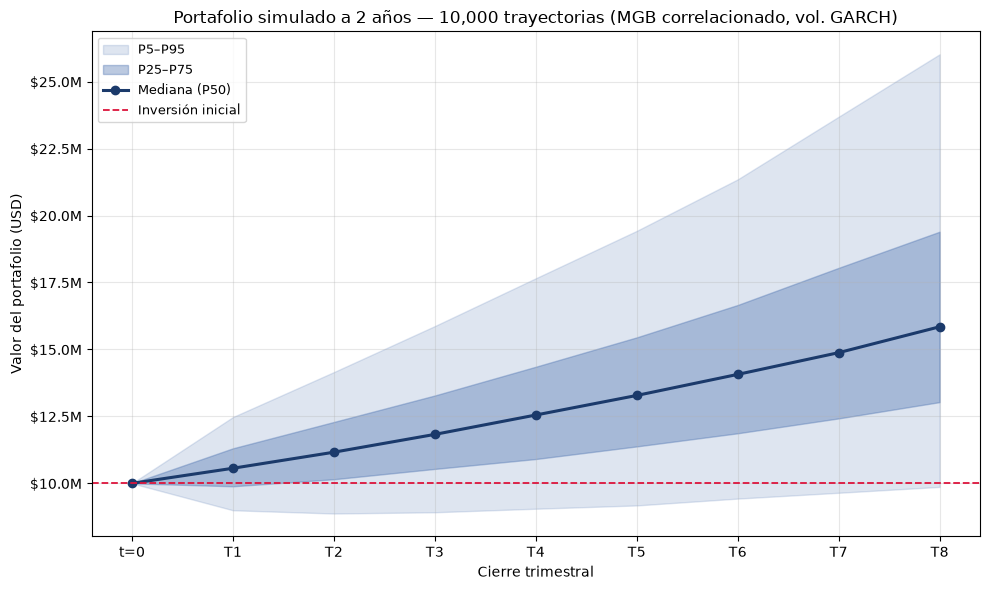

Nota: las bandas representan escenarios simulados bajo los supuestos de deriva histórica y volatilidad GARCH,
no una predicción cierta del valor futuro del portafolio.


In [53]:
# Gráfico obligatorio: bandas percentiles a 2 años, son escenarios no una predicción cierta
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(N_TRIMESTRES + 1)
ax.fill_between(x, tabla_trim["P5"], tabla_trim["P95"], color="#4c72b0", alpha=0.18, label="P5–P95")
ax.fill_between(x, tabla_trim["P25"], tabla_trim["P75"], color="#4c72b0", alpha=0.38, label="P25–P75")
ax.plot(x, tabla_trim["P50"], color="#1b3a6b", lw=2.2, marker="o", label="Mediana (P50)")
ax.axhline(portafolio_0, color="crimson", ls="--", lw=1.3, label="Inversión inicial")
ax.set_xticks(x); ax.set_xticklabels(tabla_trim.index)
ax.set_ylabel("Valor del portafolio (USD)"); ax.set_xlabel("Cierre trimestral")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"${v/1e6:,.1f}M"))
ax.set_title(f"Portafolio simulado a {HORIZONTE_ANIOS} años — {N_PATHS:,} trayectorias (MGB correlacionado, vol. GARCH)")
ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "fig_b2_2_bandas_percentiles.png", dpi=170); plt.show()

print("Nota: las bandas representan escenarios simulados bajo los supuestos de deriva histórica y volatilidad GARCH,")
print("no una predicción cierta del valor futuro del portafolio.")

La simulación muestra una trayectoria central creciente, pero con una dispersión cada vez mayor a medida que se amplía el horizonte de inversión, es decir, aumenta la incertidumbre sobre el valor futuro del portafolio.  Este comportamiento no significa necesariamente que el portafolio se vuelva **"peor" con el tiempo**, significa que aumentan los resultados posibles.

#### VaR y distribución de pérdidas - portafolio **no cubierto**

$$\text{VaR}_{95} = -Q_{0.05}(P\&L) \qquad \text{VaR}_{99} = -Q_{0.01}(P\&L)$$

con $P\&L_t = \text{Portafolio}_t - \text{Portafolio}_0$, evaluado en el **primer trimestre** (T1) y al **final de la ventana de cobertura** (T{{N_TRIMESTRES}}, {{HORIZONTE_ANIOS}} años).

In [54]:
def var_es(pnl, niveles=(0.95, 0.99)):
    out = {}
    for nivel in niveles:
        q = np.percentile(pnl, 100 * (1 - nivel))
        var = -q
        es  = -pnl[pnl <= q].mean()      # Expected Shortfall, complemento útil al VaR
        out[nivel] = (var, es)
    return out

pnl_T1_nc  = port_trim[:, 1] - portafolio_0
pnl_TN_nc  = port_trim[:, -1] - portafolio_0
var_T1_nc, var_TN_nc = var_es(pnl_T1_nc), var_es(pnl_TN_nc)

tabla_var_nc = pd.DataFrame({
    "VaR_95_USD":  [var_T1_nc[0.95][0], var_TN_nc[0.95][0]],
    "VaR_95_%cap": [var_T1_nc[0.95][0] / CAPITAL, var_TN_nc[0.95][0] / CAPITAL],
    "ES_95_USD":   [var_T1_nc[0.95][1], var_TN_nc[0.95][1]],
    "VaR_99_USD":  [var_T1_nc[0.99][0], var_TN_nc[0.99][0]],
    "VaR_99_%cap": [var_T1_nc[0.99][0] / CAPITAL, var_TN_nc[0.99][0] / CAPITAL],
    "ES_99_USD":   [var_T1_nc[0.99][1], var_TN_nc[0.99][1]],
}, index=["T1 (primer trimestre)", f"T{N_TRIMESTRES} (fin ventana, {HORIZONTE_ANIOS} años)"])
display(tabla_var_nc.style.format({c: "{:,.2%}" if "%" in c else "${:,.0f}" for c in tabla_var_nc.columns}))

,VaR_95_USD,VaR_95_%cap,ES_95_USD,VaR_99_USD,VaR_99_%cap,ES_99_USD
T1 (primer trimestre),"$1,005,113",10.05%,"$1,388,475","$1,610,773",16.11%,"$1,918,263"
"T8 (fin ventana, 2 años)","$133,003",1.33%,"$1,165,623","$1,745,728",17.46%,"$2,565,424"


la cartera presenta una cola de pérdidas relevante, especialmente al 99% de confianza. Por ello, resulta necesario complementar la cartera de mínima varianza con una estrategia de cobertura que reduzca la severidad de los escenarios adversos. La efectividad de dicha cobertura deberá evaluarse comparando el VaR y el Expected Shortfall del portafolio cubierto frente al no cubierto y relacionando esa reducción del riesgo con el costo de las primas.

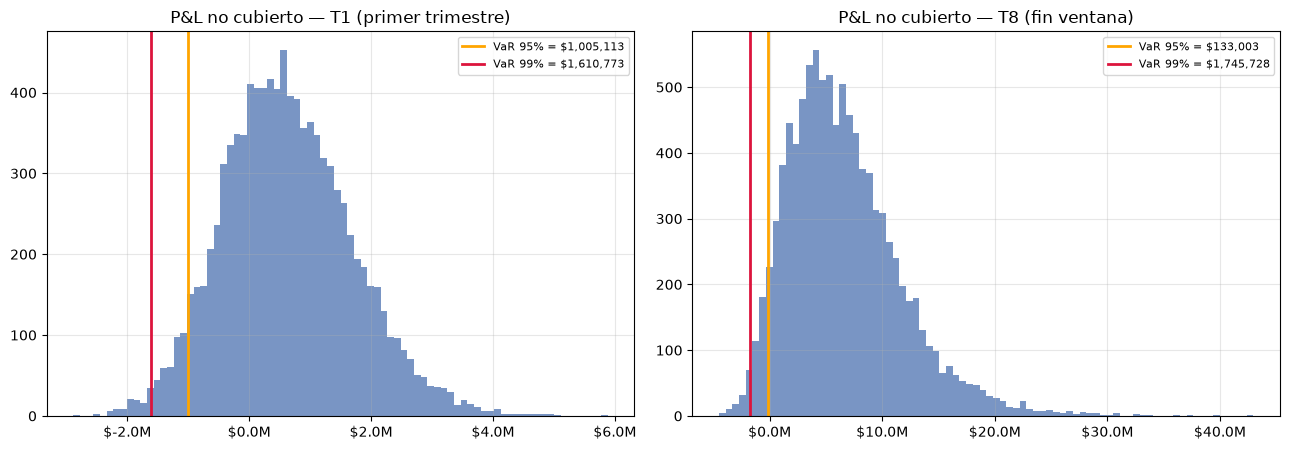

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, pnl, nombre, vres in zip(axes, [pnl_T1_nc, pnl_TN_nc],
                                  ["T1 (primer trimestre)", f"T{N_TRIMESTRES} (fin ventana)"],
                                  [var_T1_nc, var_TN_nc]):
    ax.hist(pnl, bins=80, color="#4c72b0", alpha=0.75)
    ax.axvline(-vres[0.95][0], color="orange", lw=2, label=f"VaR 95% = ${vres[0.95][0]:,.0f}")
    ax.axvline(-vres[0.99][0], color="crimson", lw=2, label=f"VaR 99% = ${vres[0.99][0]:,.0f}")
    ax.set_title(f"P&L no cubierto — {nombre}"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"${v/1e6:,.1f}M"))
fig.tight_layout(); fig.savefig(OUT / "fig_b2_3_var_no_cubierto.png", dpi=170); plt.show()

#### Cobertura preliminar y VaR del portafolio **cubierto**

Se arma una *protective put* **ATM** por activo: se compran `contratos_85%` contratos por activo, con vencimiento a {{HORIZONTE_ANIOS}} años y strike $K_i = S_{0,i}$. La prima se calcula con Black-Scholes (europea) usando $\sigma$ = volatilidad de largo plazo del GARCH, $r$ = tasa Treasury a 2 años (`RF_CC`, coherente con el vencimiento de {{HORIZONTE_ANIOS}} años) y $q$ = tasa de dividendo. El costo de la prima se reconoce explícitamente como una salida de caja al inicio (no se financia con deuda), siguiendo el criterio de apalancamiento del enunciado.

En cada cierre trimestral se **revalora la opción a mercado** (mark-to-market) con Black-Scholes y el tiempo remanente a vencimiento — el mismo espíritu de los "puntos de control trimestrales" descritos en los criterios iniciales del laboratorio.

In [56]:
def bs_put(S, K, T, sigma, r, q):
    S, T = np.asarray(S, dtype=np.float64), np.asarray(T, dtype=np.float64)
    intrinseco = np.maximum(K - S, 0.0)
    if np.isscalar(T):
        if T <= 1e-8:
            return intrinseco
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * np.maximum(T, 1e-8)) / (sigma * np.sqrt(np.maximum(T, 1e-8)))
    d2 = d1 - sigma * np.sqrt(np.maximum(T, 1e-8))
    valor = K * np.exp(-r * T) * st.norm.cdf(-d2) - S * np.exp(-q * T) * st.norm.cdf(-d1)
    return np.where(T <= 1e-8, intrinseco, valor)

import scipy.stats as st

K_put   = MONEYNESS_PUT_PRELIM * spot.values
sigma_bs = garch_resumen["vol_largo_plazo_anual"].values
r_bs, q_bs = RF_CC, q_div.values
T_hedge = HORIZONTE_ANIOS

prima_x_accion = np.array([bs_put(spot.values[i], K_put[i], T_hedge, sigma_bs[i], r_bs, q_bs[i]) for i in range(3)])
prima_total_i  = prima_x_accion * contratos_85 * TAM_CONTRATO
prima_total    = float(prima_total_i.sum())

tabla_prima = pd.DataFrame({
    "K (ATM)": K_put, "sigma_GARCH_LP": sigma_bs, "prima_x_accion": prima_x_accion,
    "contratos": contratos_85.astype(int), "prima_total_USD": prima_total_i,
}, index=TICKERS)
display(tabla_prima)
print(f"Costo total de la cobertura preliminar: USD {prima_total:,.0f} ({prima_total / CAPITAL:.2%} del capital invertido)")

,K (ATM),sigma_GARCH_LP,prima_x_accion,contratos,prima_total_USD
LLY,"1,181.8900",0.3137,152.7328,24,"366,558.6460"
ORCL,139.5400,0.5062,32.4012,103,"333,731.9582"
GD,336.2900,0.2214,30.4975,126,"384,268.0684"


Costo total de la cobertura preliminar: USD 1,084,559 (10.85% del capital invertido)


La valoración preliminar permite estimar cuánto costaría proteger aproximadamente el 85% de la posición accionaria mediante puts ATM durante dos años. Este costo debe interpretarse como el precio de transferir parte del riesgo de caída a través de la opción. Sin embargo, una prima más alta no implica necesariamente una cobertura más conveniente, ni una prima más baja significa una mejor protección. La decisión deberá comparar posteriormente el costo de la prima con la reducción efectiva del riesgo, especialmente sobre el VaR y el Expected Shortfall, y con las condiciones de liquidez observadas en el mercado.

In [57]:
# Revaloración trimestral de las puts sobre todas las trayectorias simuladas (mark-to-market)
put_value_trim = np.empty((N_PATHS, N_TRIMESTRES + 1, 3))
for i in range(N_TRIMESTRES + 1):
    T_rem = T_hedge - idx_trim[i] / DIAS_ANIO
    for k in range(3):
        put_value_trim[:, i, k] = bs_put(S_path[:, idx_trim[i], k], K_put[k], T_rem, sigma_bs[k], r_bs, q_bs[k])

valor_puts_trim = (put_value_trim * (contratos_85 * TAM_CONTRATO)).sum(axis=2)   # (N_PATHS, N_TRIMESTRES+1)
port_cub_trim   = port_trim + valor_puts_trim                                    # acciones + valor de las puts
port_cub_neto   = port_cub_trim - prima_total                                    # neto de la prima pagada al inicio

pnl_T1_c  = port_cub_neto[:, 1]  - (portafolio_0)
pnl_TN_c  = port_cub_neto[:, -1] - (portafolio_0)
var_T1_c, var_TN_c = var_es(pnl_T1_c), var_es(pnl_TN_c)

comparativo_var = pd.DataFrame({
    "VaR_95_no_cubierto": [var_T1_nc[0.95][0], var_TN_nc[0.95][0]],
    "VaR_95_cubierto":    [var_T1_c[0.95][0],  var_TN_c[0.95][0]],
    "reduccion_VaR95_%":  [1 - var_T1_c[0.95][0] / var_T1_nc[0.95][0], 1 - var_TN_c[0.95][0] / var_TN_nc[0.95][0]],
    "VaR_99_no_cubierto": [var_T1_nc[0.99][0], var_TN_nc[0.99][0]],
    "VaR_99_cubierto":    [var_T1_c[0.99][0],  var_TN_c[0.99][0]],
    "reduccion_VaR99_%":  [1 - var_T1_c[0.99][0] / var_T1_nc[0.99][0], 1 - var_TN_c[0.99][0] / var_TN_nc[0.99][0]],
}, index=["T1 (primer trimestre)", f"T{N_TRIMESTRES} (fin ventana, {HORIZONTE_ANIOS} años)"])
display(comparativo_var.style.format({c: "{:,.1%}" if "%" in c else "${:,.0f}" for c in comparativo_var.columns}))

peor_cubierto = comparativo_var.filter(like="reduccion").lt(0).any(axis=1)
if peor_cubierto.any():
    print("Nota: en", ", ".join(peor_cubierto[peor_cubierto].index),
          "el VaR cubierto sale mayor que el no cubierto en algún nivel.")
    print("No es un error: como la prima completa se reconoce desde el día 0 (sin amortizar).")
    print("En un trimestre corto ese costo hundido puede pesar más que la protección todavía")
    print("acumulada por la opción. Es un punto valido para discutir en el informe (costo vs. beneficio de")
    print("comprar cobertura a 2 años frente a la ventana de medición de cada trimestre).")

,VaR_95_no_cubierto,VaR_95_cubierto,reduccion_VaR95_%,VaR_99_no_cubierto,VaR_99_cubierto,reduccion_VaR99_%
T1 (primer trimestre),"$1,005,113","$674,247",32.9%,"$1,610,773","$1,053,034",34.6%
"T8 (fin ventana, 2 años)","$133,003","$235,432",-77.0%,"$1,745,728","$1,289,134",26.2%


Nota: en T8 (fin ventana, 2 años) el VaR cubierto sale mayor que el no cubierto en algún nivel.
No es un error: como la prima completa se reconoce desde el día 0 (sin amortizar).
En un trimestre corto ese costo hundido puede pesar más que la protección todavía
acumulada por la opción. Es un punto valido para discutir en el informe (costo vs. beneficio de
comprar cobertura a 2 años frente a la ventana de medición de cada trimestre).


La revaloración trimestral de la Protective Put permite evaluar su eficacia como instrumento de cobertura mediante la comparación del VaR del portafolio cubierto frente al portafolio no cubierto. La efectividad no se determina únicamente por la reducción del VaR, sino también por el costo de la prima y por la capacidad de la opción para reducir la severidad de las pérdidas en los escenarios extremos. Debido a que la cobertura corresponde aproximadamente al 85% de las acciones, no se espera una eliminación completa del riesgo

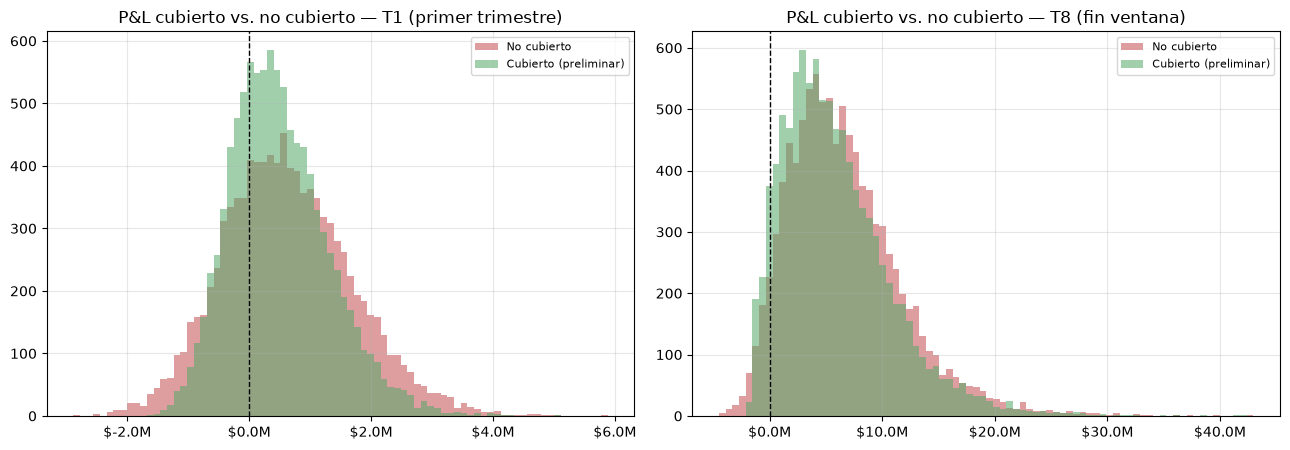

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, pnc, pc, nombre in zip(axes, [pnl_T1_nc, pnl_TN_nc], [pnl_T1_c, pnl_TN_c],
                                ["T1 (primer trimestre)", f"T{N_TRIMESTRES} (fin ventana)"]):
    bins = np.linspace(
        min(pnc.min(), pc.min()),
        max(pnc.max(), pc.max()),
        81
    )
    ax.hist(
        pnc,
        bins=bins,                         # CAMBIO 1
        alpha=0.55,
        color="#c44e52",
        label="No cubierto"
    )

    ax.hist(
        pc,
        bins=bins,                         # CAMBIO 1
        alpha=0.55,
        color="#55a868",
        label="Cubierto (preliminar)"
    )

    # CAMBIO 2: línea de equilibrio P&L = 0
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        lw=1
    )
    ax.set_title(f"P&L cubierto vs. no cubierto — {nombre}"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"${v/1e6:,.1f}M"))
fig.tight_layout(); fig.savefig(OUT / "fig_b2_4_var_cubierto_vs_no.png", dpi=170); plt.show()

“La incorporación preliminar de la Protective Put busca reducir la severidad de los escenarios de pérdida, especialmente en la cola izquierda de la distribución. No obstante, la protección implica el pago de una prima que afecta el P&L neto. Por ello, su efectividad debe evaluarse mediante la reducción del VaR y Expected Shortfall respecto al portafolio no cubierto

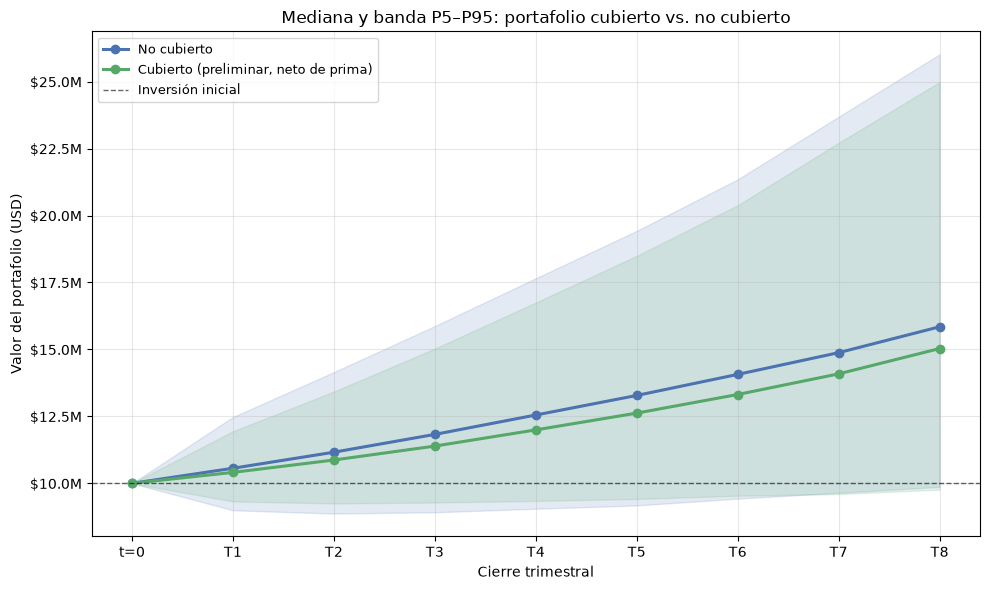

In [60]:
# Gráfico adicional (anticipa el Bloque III): portafolio cubierto vs. no cubierto en cada cierre trimestral
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(N_TRIMESTRES + 1)
for datos, color, nombre in [(port_trim, "#4c72b0", "No cubierto"), (port_cub_neto, "#55a868", "Cubierto (preliminar, neto de prima)")]:
    p50 = np.percentile(datos, 50, axis=0)
    p5, p95 = np.percentile(datos, 5, axis=0), np.percentile(datos, 95, axis=0)
    ax.fill_between(x, p5, p95, color=color, alpha=0.15)
    ax.plot(x, p50, color=color, lw=2.2, marker="o", label=nombre)
ax.axhline(portafolio_0, color="black", ls="--", lw=1, alpha=0.6, label="Inversión inicial")
ax.set_xticks(x); ax.set_xticklabels(tabla_trim.index)
ax.set_ylabel("Valor del portafolio (USD)"); ax.set_xlabel("Cierre trimestral")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"${v/1e6:,.1f}M"))
ax.set_title("Mediana y banda P5–P95: portafolio cubierto vs. no cubierto")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "fig_b2_5_cubierto_vs_no_trimestres.png", dpi=170); plt.show()

#### Vista estratégica a 10 años (contexto, ilustrativa)

El enunciado permite extender la simulación estratégica hasta 10 años. Como el MGB tiene una solución exacta en log-precio (sin sesgo de discretización), simular directamente en pasos trimestrales es estadísticamente equivalente a simular a diario y luego observar solo los cierres trimestrales — por eso aquí se usa un paso de $\Delta t = 0.25$ años y la volatilidad de **largo plazo** del GARCH (en vez del pronóstico día a día, ya innecesario a este horizonte porque el propio GARCH revierte hacia ese valor). Esta vista es **de contexto**: el VaR y la cobertura de las secciones 5–6 se calculan únicamente sobre la ventana de 2 años.

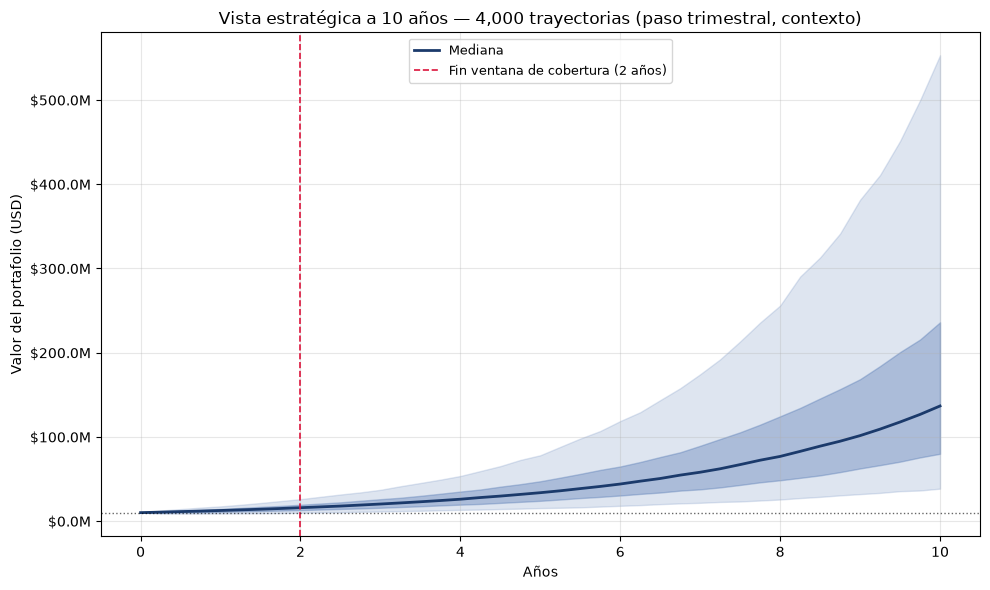

Vista de contexto a 10 años: escenarios de largo plazo, no una predicción cierta ni base de decisión de cobertura.


In [61]:
N_TRIM_10Y = 10 * 4
rng3 = np.random.default_rng(SEED + 1)
Z10  = rng3.standard_normal((N_PATHS_10Y, N_TRIM_10Y, 3))
Zc10 = Z10 @ L.T

mu_trim = mu.values * 0.25
sigma_trim = sigma_bs * np.sqrt(0.25)   # vol. de largo plazo GARCH escalada a paso trimestral

d_log10 = mu_trim[None, None, :] + sigma_trim[None, None, :] * Zc10
log_cum10 = np.cumsum(d_log10, axis=1)
log_cum10 = np.concatenate([np.zeros((N_PATHS_10Y, 1, 3)), log_cum10], axis=1)
S_path10 = spot.values[None, None, :] * np.exp(log_cum10)
port10 = (S_path10 * acciones).sum(axis=2)

x10 = np.arange(N_TRIM_10Y + 1) / 4
fig, ax = plt.subplots(figsize=(10, 6))
for p_lo, p_hi, alpha in [(5, 95, 0.18), (25, 75, 0.35)]:
    ax.fill_between(x10, np.percentile(port10, p_lo, axis=0), np.percentile(port10, p_hi, axis=0), color="#4c72b0", alpha=alpha)
ax.plot(x10, np.percentile(port10, 50, axis=0), color="#1b3a6b", lw=2, label="Mediana")
ax.axvline(HORIZONTE_ANIOS, color="crimson", ls="--", lw=1.2, label=f"Fin ventana de cobertura ({HORIZONTE_ANIOS} años)")
ax.axhline(portafolio_0, color="black", ls=":", lw=1, alpha=0.6)
ax.set_xlabel("Años"); ax.set_ylabel("Valor del portafolio (USD)")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"${v/1e6:,.1f}M"))
ax.set_title(f"Vista estratégica a 10 años — {N_PATHS_10Y:,} trayectorias (paso trimestral, contexto)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "fig_b2_6_vista_10_anios.png", dpi=170); plt.show()
print("Vista de contexto a 10 años: escenarios de largo plazo, no una predicción cierta ni base de decisión de cobertura.")

Para evaluar el comportamiento potencial del portafolio en un horizonte de diez años se implementó una simulación Monte Carlo multivariada con periodicidad trimestral, Los retornos se modelaron mediante un proceso de rendimientos logarítmicos y para ello se utilizo parámetros de retorno esperado y volatilidad escalados temporalmente. La dependencia entre los activos se incorporó mediante una descomposición de Cholesky aplicada a variables aleatorias normales estándar conservando la estructura histórica de correlaciones observada en el mercado. Posteriormente, los retornos fueron acumulados y transformados en trayectorias de precios mediante una especificación lognormal, permitiendo estimar la evolución probabilística del valor del portafolio. Los resultados se presentan mediante percentiles y la trayectoria mediana, proporcionando una visión del rango de resultados.

In [32]:
checks_b2 = {
    f"≥ 10.000 trayectorias ({N_PATHS:,})": N_PATHS >= 10_000,
    "Valores del portafolio en t=0 y en cada cierre trimestral (2 años)": tabla_trim.shape[0] == N_TRIMESTRES + 1,
    "Bandas percentiles a 2 años graficadas": (OUT / "fig_b2_2_bandas_percentiles.png").exists(),
    "Nota de que son escenarios, no una predicción cierta": True,
    f"Varianza modelada con GARCH sobre {HIST_GARCH_ANIOS} años de historia": len(rets_10y) > 252 * (HIST_GARCH_ANIOS - 1),
    "VaR_95 y VaR_99 (no cubierto) en T1 y en el fin de la ventana": tabla_var_nc.shape == (2, 6),
    "VaR recalculado sobre el portafolio cubierto": comparativo_var.shape == (2, 6),
    "Comparación de reducción de riesgo cubierto vs. no cubierto reportada": comparativo_var.filter(like="reduccion").notna().all().all(),
}
for k, v in checks_b2.items():
    print(("✅" if v else "⚠️ "), k)

✅ ≥ 10.000 trayectorias (10,000)
✅ Valores del portafolio en t=0 y en cada cierre trimestral (2 años)
✅ Bandas percentiles a 2 años graficadas
✅ Nota de que son escenarios, no una predicción cierta
✅ Varianza modelada con GARCH sobre 10 años de historia
✅ VaR_95 y VaR_99 (no cubierto) en T1 y en el fin de la ventana
✅ VaR recalculado sobre el portafolio cubierto
✅ Comparación de reducción de riesgo cubierto vs. no cubierto reportada
